In [8]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder

In [9]:
df = pd.read_csv("../Data/Raw/fake reviews dataset.csv")
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [4]:
df.columns

Index(['category', 'rating', 'label', 'text_', 'is_extreme_rating',
       'rating_deviation'],
      dtype='object')

In [11]:
df['review_length'] = df['text_'].apply(len)
# Droped word_count — 0.99 correlated with review_length

# Sentence level features
import re
df['sentence_count']     = df['text_'].apply(lambda x: len(re.split(r'[.!?]+', x)))
df['avg_sentence_length']= df['review_length'] / (df['sentence_count'] + 1)
# Fake reviews tend to have fewer, longer sentences (AI writing pattern)

# Punctuation density
df['punct_density']      = df['text_'].apply(lambda x: sum(1 for c in x if c in '.,;:!?') / (len(x)+1))

# Unique word ratio (lexical diversity)
df['unique_word_ratio']  = df['text_'].apply(lambda x: len(set(x.lower().split())) / (len(x.split())+1))
# AI generated text tends to be less lexically diverse

# Digit presence
df['has_digits']         = df['text_'].apply(lambda x: int(any(c.isdigit() for c in x)))
# Real reviews mention prices, model numbers, dates

# Repeated character detection (lazy writing like "sooooo good")
df['has_repeated_chars'] = df['text_'].apply(lambda x: int(bool(re.search(r'(.)\1{2,}', x))))

# Starts with "I" (personal experience signal — more likely genuine)
df['starts_with_I']      = df['text_'].apply(lambda x: int(x.strip().startswith('I ')))

# Category encode
le = LabelEncoder()
df['category_encoded']   = le.fit_transform(df['category'])

# Average review length per category (CG reviews shorter in some categories?)
df['cat_avg_length']     = df.groupby('category')['review_length'].transform('mean')
df['length_vs_cat_avg']  = df['review_length'] - df['cat_avg_length']

In [16]:
df['target'] = df['label'].apply(lambda x: 1 if x == 'CG' else 0)
features = [
    'review_length',
    'sentence_count',
    'avg_sentence_length',
    'punct_density',
    'unique_word_ratio',
    'has_digits',
    'has_repeated_chars',
    'starts_with_I',
    'category_encoded',
    'length_vs_cat_avg',
    'exclamation_count',   # keep but expect low importance
    'question_count',      # keep but expect low importance
]

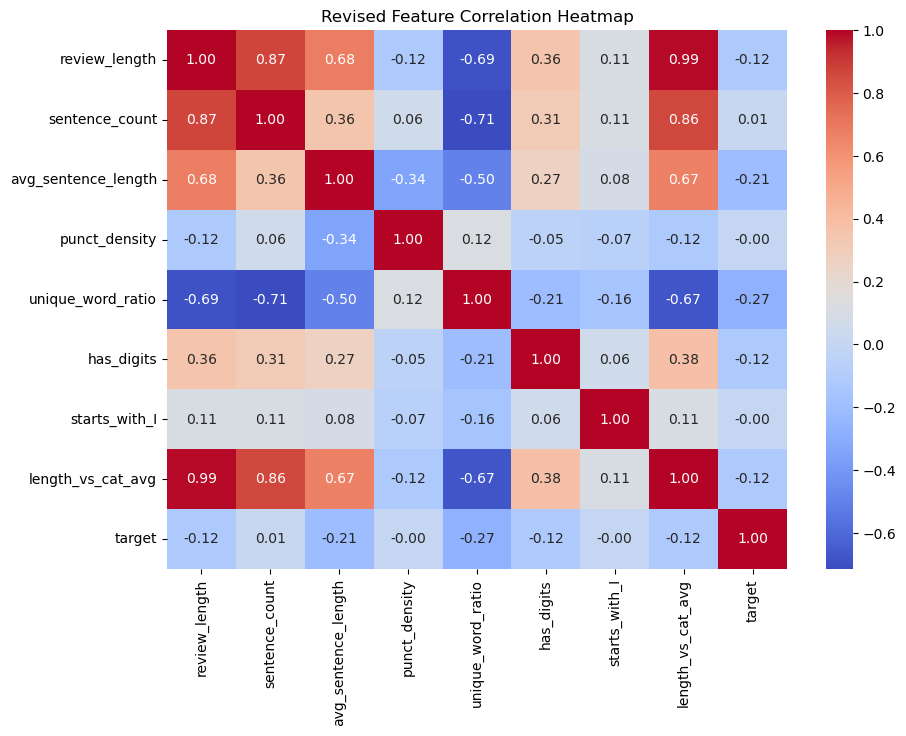

In [18]:
# Check new features correlation with target
new_features = ['review_length', 'sentence_count', 'avg_sentence_length',
                'punct_density', 'unique_word_ratio', 'has_digits',
                'starts_with_I', 'length_vs_cat_avg' ,  'target' ]

plt.figure(figsize=(10,7))
sns.heatmap(df[new_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Revised Feature Correlation Heatmap')
plt.show()

In [19]:
#Finalized features

features = [
    'unique_word_ratio',      # -0.27 with target — best feature
    'avg_sentence_length',    # -0.21 — second best
    'review_length',          # -0.12
    'has_digits',             # -0.12
]

In [21]:
df.to_csv("../Data/Processed/Processed_data.csv")